#Project Title: Aerial Object Classification & Detection

####Contributer: Raksha H M


##Project Summary



This project presents a deep learning-based system for classifying and detecting aerial objects as either birds or drones using image data. The primary objective is to enhance applications such as airspace surveillance, wildlife protection, and airport safety by accurately distinguishing between these visually similar objects.

The project is divided into two major components: image classification and object detection. For classification, multiple models were implemented, including a Custom CNN and several transfer learning models such as MobileNet, ResNet, EfficientNet, and DenseNet. Among these, MobileNet achieved the best performance, reaching an accuracy of up to 99% after fine-tuning, making it the final selected model.

For object detection, the YOLOv8 framework was used to locate and label birds and drones within images. Different variants (YOLOv8n, YOLOv8s, and YOLOv8m) were explored, with improved performance achieved through tuning parameters such as image size and confidence threshold. The model demonstrated strong detection capability, although challenges were observed in detecting drones due to their smaller size and dataset imbalance.

The entire system was deployed using Streamlit, allowing users to upload images and receive real-time predictions, including classification results, confidence scores, and detection outputs with bounding boxes.

Overall, the project demonstrates the effectiveness of combining deep learning models and real-time detection frameworks to build an intelligent aerial object recognition system with practical real-world applications.

##GitHub Link

##Importing Required Libraries

In [ ]:
# ================================
# STEP 0: IMPORT LIBRARIES
# ================================

# OS module → used to navigate folders and files
import os

# NumPy → used for numerical computations (arrays, matrices)
import numpy as np

# Matplotlib → used for plotting graphs and images
import matplotlib.pyplot as plt

# Seaborn → used for better visualization (optional but useful)
import seaborn as sns

# OpenCV → used for image reading and processing
import cv2

# PIL → used to check corrupted images
from PIL import Image

# Counter → useful for counting class labels
from collections import Counter

# TensorFlow Image Generator → used later for preprocessing + loading images
from tensorflow.keras.preprocessing.image import ImageDataGenerator

##LOADING DATASET

In [ ]:
# ================================
# CHECK FILES IN COLAB
# ================================

import os

print(os.listdir('/content'))

['.config', 'valid-20260407T144036Z-3-001.zip', 'test-20260407T144032Z-3-001.zip', 'train-20260407T144032Z-3-001.zip', 'sample_data']


In [ ]:
# ================================
# EXTRACT ZIP FILES
# ================================

import zipfile

zip_files = ['train-20260407T144032Z-3-001.zip', 'valid-20260407T144036Z-3-001.zip', 'test-20260407T144032Z-3-001.zip']

for zip_file in zip_files:
    zip_path = os.path.join('/content', zip_file)

    print(f"Extracting {zip_file}...")

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content')

print("All files extracted successfully!")

Extracting train-20260407T144032Z-3-001.zip...
Extracting valid-20260407T144036Z-3-001.zip...
Extracting test-20260407T144032Z-3-001.zip...
All files extracted successfully!


In [ ]:
# ================================
# CHECK EXTRACTED FOLDERS
# ================================

print(os.listdir('/content'))

['.config', 'valid-20260407T144036Z-3-001', 'valid-20260407T144036Z-3-001.zip', 'test-20260407T144032Z-3-001.zip', 'test-20260407T144032Z-3-001', 'train-20260407T144032Z-3-001', 'train-20260407T144032Z-3-001.zip', 'sample_data']


In [ ]:
# ================================
# DEFINE DATASET PATHS
# ================================

train_dir = "/content/train-20260407T144032Z-3-001"
val_dir   = "/content/valid-20260407T144036Z-3-001"
test_dir  = "/content/test-20260407T144032Z-3-001"

In [ ]:
# ================================
# VERIFY PATHS
# ================================

import os

print("Train exists:", os.path.exists(train_dir))
print("Validation exists:", os.path.exists(val_dir))
print("Test exists:", os.path.exists(test_dir))

Train exists: True
Validation exists: True
Test exists: True


##VERIFYING DATASET STRUCTURE

In [ ]:
# ================================
# CHECK TRAIN FOLDER STRUCTURE
# ================================

print("TRAIN folder contains:")
print(os.listdir(train_dir))

TRAIN folder contains:
['train']


In [ ]:
# ================================
# CHECK VALIDATION FOLDER
# ================================

print("VALID folder contains:")
print(os.listdir(val_dir))

VALID folder contains:
['valid']


In [ ]:
# ================================
# CHECK TEST FOLDER
# ================================

print("TEST folder contains:")
print(os.listdir(test_dir))

TEST folder contains:
['test']


In [ ]:
# ================================
# FIX TRAIN STRUCTURE
# ================================

import shutil

# Move bird and drone folders up
inner_train_path = os.path.join(train_dir, "train")

for folder in os.listdir(inner_train_path):
    shutil.move(os.path.join(inner_train_path, folder), train_dir)

# Remove extra 'train' folder
os.rmdir(inner_train_path)

print("TRAIN structure fixed!")

TRAIN structure fixed!


In [ ]:
# ================================
# FIX VALID STRUCTURE
# ================================

inner_val_path = os.path.join(val_dir, "valid")

for folder in os.listdir(inner_val_path):
    shutil.move(os.path.join(inner_val_path, folder), val_dir)

os.rmdir(inner_val_path)

print("VALID structure fixed!")

VALID structure fixed!


In [ ]:
# ================================
# FIX TEST STRUCTURE
# ================================

inner_test_path = os.path.join(test_dir, "test")

for folder in os.listdir(inner_test_path):
    shutil.move(os.path.join(inner_test_path, folder), test_dir)

os.rmdir(inner_test_path)

print("TEST structure fixed!")

TEST structure fixed!


In [ ]:
# ================================
# VERIFY FINAL STRUCTURE
# ================================

print("TRAIN:", os.listdir(train_dir))
print("VALID:", os.listdir(val_dir))
print("TEST:", os.listdir(test_dir))

TRAIN: ['bird', 'drone']
VALID: ['bird', 'drone']
TEST: ['bird', 'drone']


In [ ]:
# ================================
# CHECK IMAGE COUNT IN EACH CLASS
# ================================

def check_class_images(folder_path):
    for class_name in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_name)
        num_images = len(os.listdir(class_path))

        print(f"{folder_path} → {class_name}: {num_images} images")

# Check all datasets
print("TRAIN DATA:")
check_class_images(train_dir)

print("\nVALID DATA:")
check_class_images(val_dir)

print("\nTEST DATA:")
check_class_images(test_dir)

TRAIN DATA:
/content/train-20260407T144032Z-3-001 → bird: 1414 images
/content/train-20260407T144032Z-3-001 → drone: 1248 images

VALID DATA:
/content/valid-20260407T144036Z-3-001 → bird: 217 images
/content/valid-20260407T144036Z-3-001 → drone: 225 images

TEST DATA:
/content/test-20260407T144032Z-3-001 → bird: 121 images
/content/test-20260407T144032Z-3-001 → drone: 94 images


##DATA INTEGRITY CHECK

In [ ]:
# ================================
# STEP 3: REMOVE CORRUPTED IMAGES
# ================================

from PIL import Image

def clean_dataset(folder_path):
    """
    This function:
    - Goes through each class folder (bird/drone)
    - Tries to open every image
    - Removes image if corrupted
    """

    print(f"\nChecking folder: {folder_path}")

    for class_name in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_name)

        print(f"  Checking class: {class_name}")

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            try:
                # Try opening the image
                img = Image.open(img_path)

                # Verify image integrity
                img.verify()

            except Exception as e:
                # If error occurs → image is corrupted
                print(f"  Removing corrupted image: {img_path}")
                os.remove(img_path)

In [ ]:
# ================================
# APPLY CLEANING
# ================================

clean_dataset(train_dir)
clean_dataset(val_dir)
clean_dataset(test_dir)

print("\n✅ Data cleaning completed!")


Checking folder: /content/train-20260407T144032Z-3-001
  Checking class: bird
  Checking class: drone

Checking folder: /content/valid-20260407T144036Z-3-001
  Checking class: bird
  Checking class: drone

Checking folder: /content/test-20260407T144032Z-3-001
  Checking class: bird
  Checking class: drone

✅ Data cleaning completed!


##IMAGE SIZE ANAYSIS, RESIZING, NORMALIZATION AND DATA AUGMENTATION


In [ ]:
# ================================
# STEP 4: CHECK IMAGE SIZES
# ================================

def get_image_sizes(folder_path, sample_size=50):
    """
    Collects image sizes from dataset

    Parameters:
    - folder_path: TRAIN/VALID/TEST folder
    - sample_size: number of images to check per class
    """

    sizes = []

    for class_name in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_name)

        images = os.listdir(class_path)[:sample_size]

        for img_name in images:
            img_path = os.path.join(class_path, img_name)

            img = cv2.imread(img_path)

            if img is not None:
                height, width = img.shape[:2]
                sizes.append((height, width))

    return sizes

In [ ]:
# Get sizes from TRAIN dataset
sizes = get_image_sizes(train_dir)

# Print some sample sizes
print("Sample image sizes:")
print(sizes[:20])

Sample image sizes:
[(416, 416), (416, 416), (416, 416), (416, 416), (416, 416), (416, 416), (416, 416), (416, 416), (416, 416), (416, 416), (416, 416), (416, 416), (416, 416), (416, 416), (416, 416), (416, 416), (416, 416), (416, 416), (416, 416), (416, 416)]


In [ ]:
# ================================
# ANALYZE SIZE DISTRIBUTION
# ================================

# Convert to separate lists
heights = [s[0] for s in sizes]
widths  = [s[1] for s in sizes]

print("Min Height:", min(heights))
print("Max Height:", max(heights))

print("Min Width:", min(widths))
print("Max Width:", max(widths))

Min Height: 416
Max Height: 416
Min Width: 416
Max Width: 416


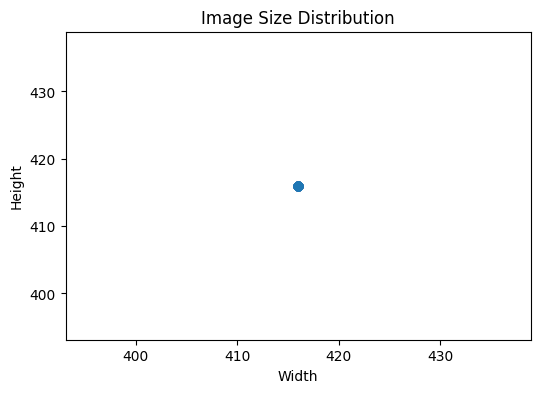

In [ ]:
#visulization using scatterplot
plt.figure(figsize=(6,4))
plt.scatter(widths, heights)
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image Size Distribution")
plt.show()

In [ ]:
# ================================
# STEP 5: DEFINE PARAMETERS
# ================================

IMG_SIZE = (224, 224)   # Target image size
BATCH_SIZE = 32         # Number of images per batch

In [ ]:
# ================================
# TRAIN DATA GENERATOR
# ================================

train_datagen = ImageDataGenerator(

    # 🔹 Normalization
    rescale=1./255,

    # 🔹 Augmentation (only for training)
    rotation_range=20,        # Rotate images
    width_shift_range=0.2,    # Horizontal shift
    height_shift_range=0.2,   # Vertical shift
    zoom_range=0.2,           # Zoom in/out
    horizontal_flip=True,     # Flip images
    brightness_range=[0.8, 1.2],# Brightness variation
    shear_range=0.2,
    vertical_flip=True,

    fill_mode='nearest'       # Fill empty pixels after transformation
)

In [ ]:
# ================================
# VALIDATION & TEST GENERATOR
# ================================

val_test_datagen = ImageDataGenerator(

    # Only normalization
    rescale=1./255
)

In [ ]:
# ================================
# STEP 6: TRAIN DATA GENERATOR
# ================================

train_generator = train_datagen.flow_from_directory(

    train_dir,              # Path to TRAIN folder

    target_size=IMG_SIZE,   # Resize images to (224, 224)

    batch_size=BATCH_SIZE,  # Number of images per batch

    class_mode='binary',    # Binary classification (bird vs drone)

    shuffle=True            # Shuffle data (VERY IMPORTANT for training)
)

Found 2662 images belonging to 2 classes.


In [ ]:
# ================================
# VALIDATION DATA GENERATOR
# ================================

val_generator = val_test_datagen.flow_from_directory(

    val_dir,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='binary',

    shuffle=True   # Optional (can be True/False)
)

Found 442 images belonging to 2 classes.


In [ ]:
# ================================
# TEST DATA GENERATOR
# ================================

test_generator = val_test_datagen.flow_from_directory(

    test_dir,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='binary',

    shuffle=False   # VERY IMPORTANT (for correct evaluation)
)

Found 215 images belonging to 2 classes.


##VERIFY IMAGES AND LABLES , HANDLING CLASS WEIGHTS

In [ ]:
# ================================
# STEP 7: FETCH ONE BATCH
# ================================

images, labels = next(train_generator)

print("Shape of images:", images.shape)
print("Shape of labels:", labels.shape)

Shape of images: (32, 224, 224, 3)
Shape of labels: (32,)


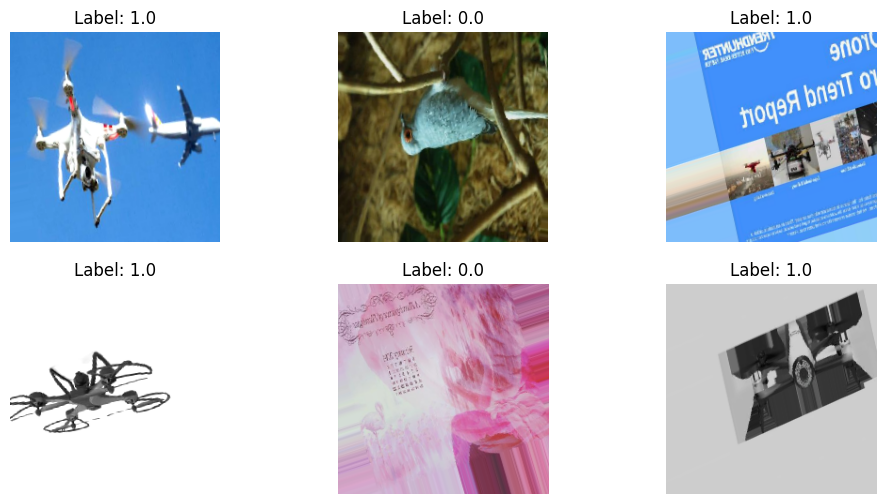

In [ ]:
# ================================
# DISPLAY SAMPLE IMAGES
# ================================

plt.figure(figsize=(12,6))

for i in range(6):  # show 6 images

    plt.subplot(2,3,i+1)

    plt.imshow(images[i])   # image

    plt.title(f"Label: {labels[i]}")

    plt.axis("off")

plt.show()

In [ ]:
# ================================
# CHECK CLASS LABEL MAPPING
# ================================

print(train_generator.class_indices)

{'bird': 0, 'drone': 1}


In [ ]:
# ================================
# STEP 8: COMPUTE CLASS WEIGHTS
# ================================

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Get class labels from generator
classes = train_generator.classes

# Compute weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes),
    y=classes
)

# Convert to dictionary format
class_weights = dict(enumerate(class_weights))

print("Class Weights:", class_weights)

Class Weights: {0: np.float64(0.9413012729844413), 1: np.float64(1.0665064102564104)}


#MODEL Building(Custom CNN)

###What is a CNN?

  A CNN is a deep learning model that:

    Detects patterns in images
      Learns features like:
        🔹Edges
        🔹Shapes
        🔹Objects (bird / drone)


###CNN Architecture Overview

    🔹A typical CNN looks like:

    Input Image → Conv → ReLU → Pool → Conv → ReLU → Pool → Flatten → Dense → Output




###Model Plan



#####BLOCK 1
    🔹Conv Layer (32 filters)
    🔹ReLU activation
    🔹MaxPooling

    👉 Learns basic features (edges)

#####BLOCK 2
    🔹Conv Layer (64 filters)
    🔹ReLU
    🔹MaxPooling

    👉 Learns shapes

#####BLOCK 3
    🔹Conv Layer (128 filters)
    🔹ReLU
    🔹MaxPooling

    👉 Learns complex patterns

#####REGULARIZATION


    🔹Batch Normalization
    🔹Dropout

    👉 Reason:

      🔹Prevents overfitting
      🔹Improves stability

#####FULLY CONNECTED LAYER
    🔹Flatten
    🔹Dense layer
    🔹Dropout

#####OUTPUT LAYER
    🔹1 neuron + sigmoid activation
    👉 Because:
        🔹Binary classification (bird vs drone)

####COMPONENTS AND THEIR PURPOSE
    🔹Component	      🔹Purpose
    Conv Layers	      Feature extraction
    Pooling	          Reduce size
    BatchNorm	      Stabilize training
    Dropout	          Prevent overfitting
    Dense	          Final decision


####IMPORTANT DESIGN DECISIONS

    🔹 Input Shape: (224, 224, 3)
    🔹 Activation: Hidden layers → ReLU
                    Output → Sigmoid
    🔹 Loss Function: binary_crossentropy
    🔹 Optimizer: Adam

###IMPORTING CNN LIBRARIES

In [ ]:
# ================================
# STEP 10: IMPORT CNN LIBRARIES
# ================================

from tensorflow.keras.models import Sequential   # To build model layer-by-layer

from tensorflow.keras.layers import (
    Conv2D,        # Convolution layer (feature extraction)
    MaxPooling2D,  # Reduce spatial size
    Flatten,       # Convert 2D → 1D
    Dense,         # Fully connected layer
    Dropout,       # Prevent overfitting
    BatchNormalization  # Stabilize training
)
from tensorflow.keras.regularizers import l2

# ================================
# INITIALIZE MODEL
# ================================

model = Sequential()

###CNN Block 1 (Basic Feature Extraction)

In [ ]:
# ================================
# BLOCK 1: FIRST CONVOLUTION LAYER
# ================================

model.add(Conv2D(
    filters=32,                 # Number of filters (feature detectors)
    kernel_size=(3,3),          # Size of filter
    activation='relu',          # Activation function
    kernel_regularizer=l2(0.001),
    input_shape=(224, 224, 3)   # Input image shape
))
# ================================
# BATCH NORMALIZATION
# ================================

model.add(BatchNormalization())

# ================================
# MAX POOLING
# ================================

model.add(MaxPooling2D(
    pool_size=(2,2)   # Reduce size by half
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


###CNN Block 2 (Intermediate Feature Extraction)

In [ ]:
# ================================
# BLOCK 2: SECOND CONVOLUTION LAYER
# ================================

model.add(Conv2D(
    filters=64,          # Increased filters → more feature learning
    kernel_size=(3,3),
    activation='relu',
    kernel_regularizer=l2(0.001)
))

# ================================
# BATCH NORMALIZATION
# ================================

model.add(BatchNormalization())

# ================================
# MAX POOLING
# ================================

model.add(MaxPooling2D(pool_size=(2,2)))

###CNN Block 3 (Deep Feature Extraction)

In [ ]:
# ================================
# BLOCK 3: THIRD CONVOLUTION LAYER
# ================================

model.add(Conv2D(
    filters=128,         # More filters → deeper feature learning
    kernel_size=(3,3),
    activation='relu',
    kernel_regularizer=l2(0.001)
))

# ================================
# BATCH NORMALIZATION
# ================================

model.add(BatchNormalization())

# ================================
# MAX POOLING
# ================================

model.add(MaxPooling2D(pool_size=(2,2)))

###Flatten + Dense Layers (Decision Making)

In [ ]:
# ================================
# FLATTEN LAYER
# ================================

model.add(Flatten())

# ================================
# FULLY CONNECTED LAYER
# ================================

model.add(Dense(
    128,                # Number of neurons
    activation='relu'   # Activation
))

# DROPOUT LAYER

model.add(Dropout(0.5))   # 50% neurons randomly turned off



# ================================
# OUTPUT LAYER
# ================================

model.add(Dense(
    1,                  # 1 neuron (binary classification)
    activation='sigmoid'
))

###Compile the CNN Model

In [ ]:
# ================================
# COMPILE (TUNED)
# ================================

from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0003),   # optimizer, lower LR
    loss='binary_crossentropy',  #loss function
    metrics=['accuracy']   #accuracy metrics
)

# ================================
# MODEL SUMMARY
# ================================

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,985 (42.61 MB)

 Trainable params: 11,169,537 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

###Train the CNN Model

In [ ]:
# ================================
# STEP 16: IMPORT CALLBACKS
# ================================

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# ================================
# DEFINE CALLBACKS
# ================================

# Stop training if validation loss doesn't improve
early_stop = EarlyStopping(
    monitor='val_loss',     # Watch validation loss
    patience=6,             # Wait 5 epochs before stopping
    restore_best_weights=True
)

# Save best model
checkpoint = ModelCheckpoint(
    "best_model.h5",        # File name
    monitor='val_loss',     # Save based on validation loss
    save_best_only=True
)



# ================================
# TRAIN MODEL
# ================================

history = model.fit(

    train_generator,             # Training data

    validation_data=val_generator,  # Validation data

    epochs=20,                  # Max number of epochs

    class_weight=class_weights, # Handle imbalance

    callbacks=[early_stop, checkpoint]  # Apply callbacks
)

Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 517ms/step - accuracy: 0.6377 - loss: 2.9067

84/84 ━━━━━━━━━━━━━━━━━━━━ 59s 569ms/step - accuracy: 0.6612 - loss: 2.0300 - val_accuracy: 0.4910 - val_loss: 5.7193
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 40s 472ms/step - accuracy: 0.7017 - loss: 0.7864 - val_accuracy: 0.4910 - val_loss: 7.1355
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 39s 465ms/step - accuracy: 0.7122 - loss: 0.7811 - val_accuracy: 0.4910 - val_loss: 12.6174
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.7382 - loss: 0.7166

84/84 ━━━━━━━━━━━━━━━━━━━━ 39s 467ms/step - accuracy: 0.7352 - loss: 0.7473 - val_accuracy: 0.6697 - val_loss: 1.4990
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.7112 - loss: 0.7539

84/84 ━━━━━━━━━━━━━━━━━━━━ 39s 468ms/step - accuracy: 0.7231 - loss: 0.7162 - val_accuracy: 0.6471 - val_loss: 1.0838
Epoch 6/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - accuracy: 0.7639 - loss: 0.6574

84/84 ━━━━━━━━━━━━━━━━━━━━ 39s 468ms/step - accuracy: 0.7536 - loss: 0.6565 - val_accuracy: 0.6900 - val_loss: 0.7554
Epoch 7/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - accuracy: 0.7541 - loss: 0.6545

...

84/84 ━━━━━━━━━━━━━━━━━━━━ 39s 467ms/step - accuracy: 0.7596 - loss: 0.6463 - val_accuracy: 0.7986 - val_loss: 0.5887
Epoch 9/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 39s 468ms/step - accuracy: 0.7615 - loss: 0.6303 - val_accuracy: 0.7738 - val_loss: 0.5999
Epoch 10/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.7664 - loss: 0.5949

84/84 ━━━━━━━━━━━━━━━━━━━━ 40s 471ms/step - accuracy: 0.7724 - loss: 0.5886 - val_accuracy: 0.7828 - val_loss: 0.5737
Epoch 11/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 39s 467ms/step - accuracy: 0.7678 - loss: 0.6196 - val_accuracy: 0.6923 - val_loss: 0.7426
Epoch 12/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 39s 460ms/step - accuracy: 0.7765 - loss: 0.5979 - val_accuracy: 0.7624 - val_loss: 0.6789
Epoch 13/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.7880 - loss: 0.5870

84/84 ━━━━━━━━━━━━━━━━━━━━ 39s 467ms/step - accuracy: 0.7817 - loss: 0.5933 - val_accuracy: 0.7760 - val_loss: 0.5546
Epoch 14/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 39s 467ms/step - accuracy: 0.7885 - loss: 0.5860 - val_accuracy: 0.6493 - val_loss: 0.7807
Epoch 15/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 41s 489ms/step - accuracy: 0.7814 - loss: 0.6008 - val_accuracy: 0.7986 - val_loss: 0.5665
Epoch 16/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.8028 - loss: 0.5505

84/84 ━━━━━━━━━━━━━━━━━━━━ 40s 473ms/step - accuracy: 0.7975 - loss: 0.5676 - val_accuracy: 0.7738 - val_loss: 0.5377
Epoch 17/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 40s 469ms/step - accuracy: 0.7919 - loss: 0.5826 - val_accuracy: 0.7873 - val_loss: 0.5516
Epoch 18/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.8008 - loss: 0.5523

84/84 ━━━━━━━━━━━━━━━━━━━━ 40s 470ms/step - accuracy: 0.8032 - loss: 0.5478 - val_accuracy: 0.8077 - val_loss: 0.5191
Epoch 19/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 39s 467ms/step - accuracy: 0.8024 - loss: 0.5373 - val_accuracy: 0.8009 - val_loss: 0.5387
Epoch 20/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 39s 463ms/step - accuracy: 0.8140 - loss: 0.5349 - val_accuracy: 0.7692 - val_loss: 0.5960


###Training Analysis (Accuracy & Loss Graphs)

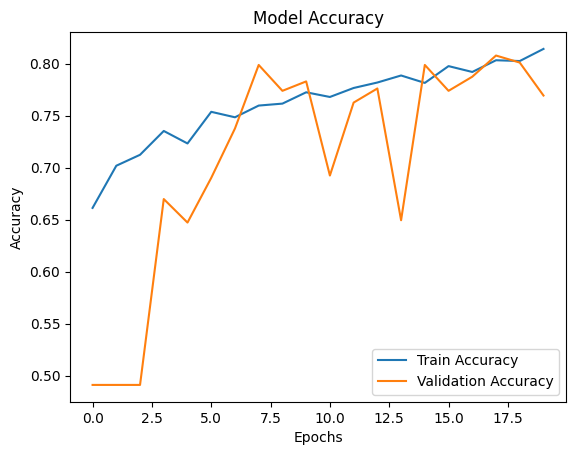

In [ ]:
# ================================
# PLOT ACCURACY GRAPH
# ================================

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

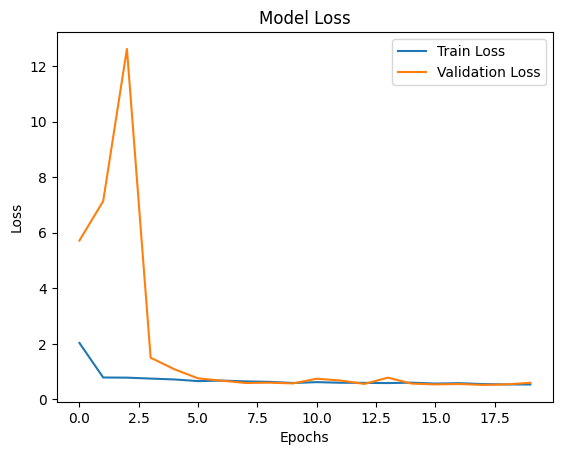

In [ ]:
# ================================
# PLOT LOSS GRAPH
# ================================

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

###Model Evaluation (Confusion Matrix + Classification Report)

In [ ]:
# ================================
# GET PREDICTIONS
# ================================

# Predict on test data
predictions = model.predict(test_generator)

# Convert probabilities → binary (0 or 1)
y_pred = (predictions > 0.5).astype(int).reshape(-1)

# ================================
# TRUE LABELS
# ================================

y_true = test_generator.classes

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 269ms/step


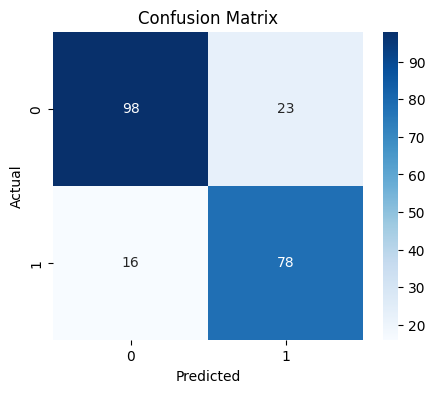

In [ ]:
# ================================
# CONFUSION MATRIX
# ================================

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

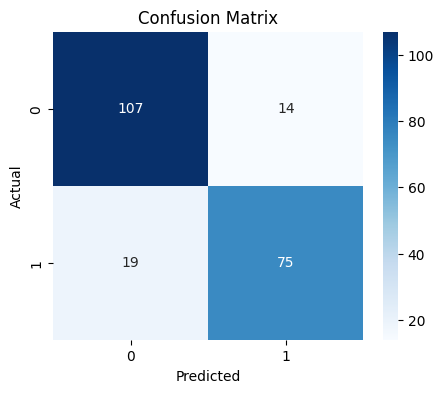

In [ ]:
# ================================
# CLASSIFICATION REPORT
# ================================

from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=['Bird', 'Drone']
))

              precision    recall  f1-score   support

        Bird       0.86      0.81      0.83       121
       Drone       0.77      0.83      0.80        94

    accuracy                           0.82       215
   macro avg       0.82      0.82      0.82       215
weighted avg       0.82      0.82      0.82       215



                      precision    recall  f1-score   support

        Bird              0.85      0.88      0.87       121
       Drone              0.84      0.80      0.82        94

    accuracy                                  0.85       215
    macro avg             0.85      0.84      0.84       215
    weighted avg          0.85      0.85      0.85       215

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 824ms/step
Raw Prediction: 0.086911626
Prediction: Bird
Confidence: 0.91


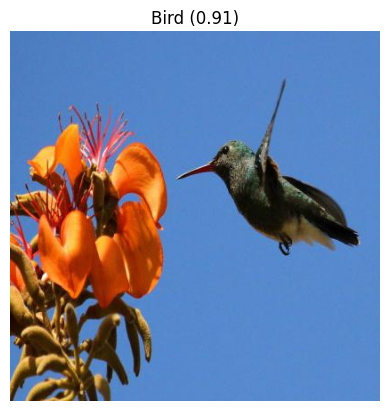

In [ ]:
# ================================
# IMPORT LIBRARIES
# ================================

import numpy as np
import cv2
import matplotlib.pyplot as plt

# ================================
# LOAD IMAGE
# ================================

img_path = "/content/test-20260407T144032Z-3-001/bird/0332627ee6c51e95_jpg.rf.a1258b27cf9ece82cdc34738320d6ea9.jpg"   # 🔴 change this to your image path

# Read image
img = cv2.imread(img_path)

# Convert BGR → RGB (important for correct colors)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Resize image
img_resized = cv2.resize(img, (224, 224))

# Normalize
img_normalized = img_resized / 255.0

# Add batch dimension
img_input = np.expand_dims(img_normalized, axis=0)

# ================================
# PREDICTION
# ================================

prediction = model.predict(img_input)[0][0]

print("Raw Prediction:", prediction)

# ================================
# INTERPRET RESULT
# ================================

if prediction > 0.5:
    label = "Drone"
else:
    label = "Bird"

confidence = prediction if prediction > 0.5 else 1 - prediction

print(f"Prediction: {label}")
print(f"Confidence: {confidence:.2f}")

# ================================
# SHOW IMAGE
# ================================

plt.imshow(img)
plt.title(f"{label} ({confidence:.2f})")
plt.axis('off')
plt.show()

##TRANSFER LEARNING-PHASE:1(MobileNetV2)

In [ ]:
# ================================
# TRANSFER LEARNING - PHASE 1
# ================================

# 🔹 Import Libraries
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# ================================
# LOAD PRETRAINED MODEL
# ================================

base_model = MobileNetV2(
    weights='imagenet',        # Use pretrained weights
    include_top=False,         # Remove original classifier
    input_shape=(224, 224, 3)
)

# Freeze base model
for layer in base_model.layers:
    layer.trainable = False

# ================================
# BUILD MODEL
# ================================

model = Sequential()

model.add(base_model)

# Convert feature maps → vector
model.add(GlobalAveragePooling2D())

# Dense layer
model.add(Dense(128, activation='relu'))

# Dropout (prevent overfitting)
model.add(Dropout(0.5))

# Output layer
model.add(Dense(1, activation='sigmoid'))

# ================================
# COMPILE MODEL
# ================================

model.compile(
    optimizer=Adam(learning_rate=0.0001),  # Low LR for transfer learning
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ================================
# CALLBACKS
# ================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "mobilenet_phase1.keras",
    monitor='val_loss',
    save_best_only=True
)


# ================================
# TRAIN MODEL (PHASE 1)
# ================================

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint]
)




9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 83s 776ms/step - accuracy: 0.7442 - loss: 0.5197 - val_accuracy: 0.9502 - val_loss: 0.2160
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 39s 461ms/step - accuracy: 0.9031 - loss: 0.2543 - val_accuracy: 0.9480 - val_loss: 0.1515
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 39s 458ms/step - accuracy: 0.9162 - loss: 0.2102 - val_accuracy: 0.9525 - val_loss: 0.1287
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 457ms/step - accuracy: 0.9358 - loss: 0.1804 - val_accuracy: 0.9570 - val_loss: 0.1173
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 451ms/step - accuracy: 0.9346 - loss: 0.1655 - val_accuracy: 0.9683 - val_loss: 0.1088
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 454ms/step - accuracy: 0.9395 - loss: 0.1527 - val_accuracy: 0.9683 - val_loss: 0.1028
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 455ms/step - accuracy: 0.9474 - loss: 0.1364 - val_accuracy: 0.9661 - val_loss: 0.0992
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 453ms/step - accuracy: 0.9500 - loss: 0.1349 - val_accu

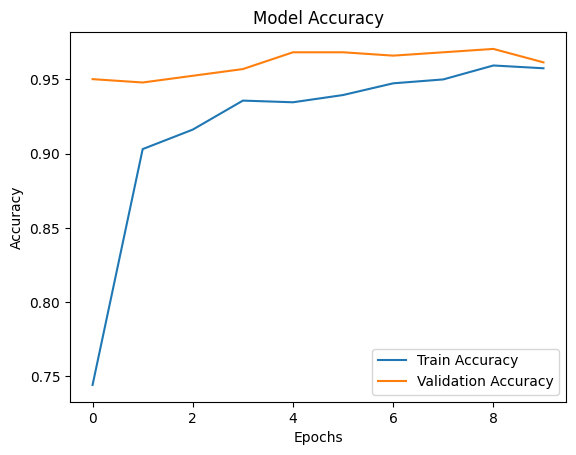

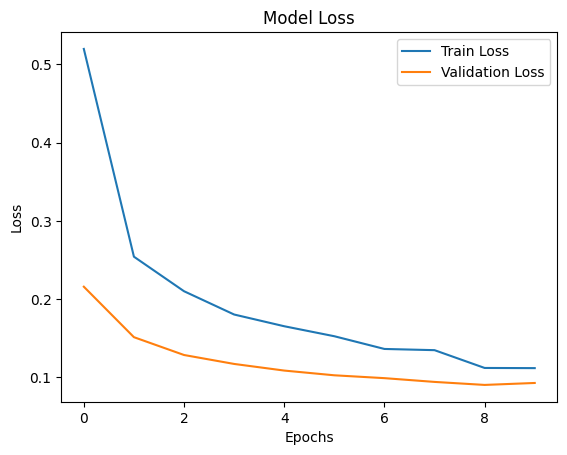

In [ ]:
# ================================
# PLOT ACCURACY GRAPH
# ================================

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

# ================================
# PLOT LOSS GRAPH
# ================================

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

6/7 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step

7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step


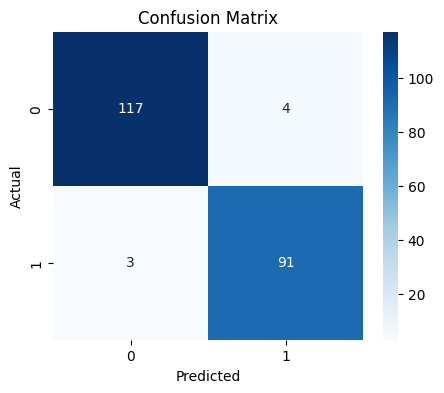

In [ ]:
# ================================
# GET PREDICTIONS
# ================================

# Predict on test data
predictions = model.predict(test_generator)

# Convert probabilities → binary (0 or 1)
y_pred = (predictions > 0.5).astype(int).reshape(-1)

# ================================
# TRUE LABELS
# ================================

y_true = test_generator.classes

# ================================
# CONFUSION MATRIX
# ================================

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
# ================================
# CLASSIFICATION REPORT
# ================================

from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=['Bird', 'Drone']
))

              precision    recall  f1-score   support

        Bird       0.97      0.97      0.97       121
       Drone       0.96      0.97      0.96        94

    accuracy                           0.97       215
   macro avg       0.97      0.97      0.97       215
weighted avg       0.97      0.97      0.97       215



MObileNetV2 (FineTuning)

In [ ]:
# ================================
# TRANSFER LEARNING - PHASE 2 (FINE-TUNING)
# ================================

# 🔹 Unfreeze top layers of base model

for layer in base_model.layers[-30:]:   # unfreeze last 30 layers
    layer.trainable = True

# ================================
# RECOMPILE MODEL (VERY IMPORTANT)
# ================================

from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),  # very low LR
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

# ================================
# CALLBACKS
# ================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "mobilenet_phase2.keras",
    monitor='val_loss',
    save_best_only=True
)

# ================================
# TRAIN AGAIN
# ================================

history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint]
)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 1,690,497 (6.45 MB)

 Non-trainable params: 731,584 (2.79 MB)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 71s 638ms/step - accuracy: 0.9361 - loss: 0.1664 - val_accuracy: 0.9570 - val_loss: 0.0965
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 453ms/step - accuracy: 0.9395 - loss: 0.1520 - val_accuracy: 0.9525 - val_loss: 0.1094
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 452ms/step - accuracy: 0.9478 - loss: 0.1338 - val_accuracy: 0.9570 - val_loss: 0.1009
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 39s 460ms/step - accuracy: 0.9519 - loss: 0.1188 - val_accuracy: 0.9638 - val_loss: 0.0918
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 457ms/step - accuracy: 0.9583 - loss: 0.1135 - val_accuracy: 0.9661 - val_loss: 0.0862
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 457ms/step - accuracy: 0.9587 - loss: 0.1025 - val_accuracy: 0.9706 - val_loss: 0.0855
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 451ms/step - accuracy: 0.9677 - loss: 0.0845 - val_accuracy: 0.9683 - val_loss: 0.0902
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 452ms/step - accuracy: 0.9658 - loss: 0.0887 - val_accu

7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 728ms/step


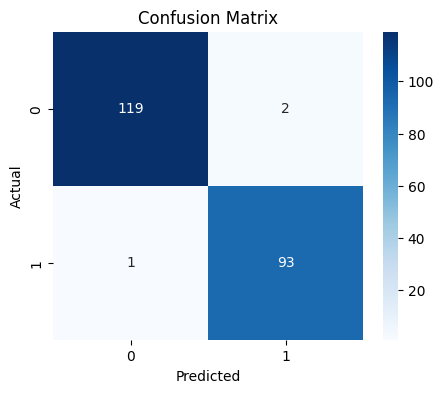

In [ ]:
# ================================
# GET PREDICTIONS
# ================================

# Predict on test data
predictions = model.predict(test_generator)

# Convert probabilities → binary (0 or 1)
y_pred = (predictions > 0.5).astype(int).reshape(-1)

# ================================
# TRUE LABELS
# ================================

y_true = test_generator.classes

# ================================
# CONFUSION MATRIX
# ================================

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
# ================================
# CLASSIFICATION REPORT
# ================================

from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=['Bird', 'Drone']
))

              precision    recall  f1-score   support

        Bird       0.99      0.98      0.99       121
       Drone       0.98      0.99      0.98        94

    accuracy                           0.99       215
   macro avg       0.99      0.99      0.99       215
weighted avg       0.99      0.99      0.99       215



###EfficientNetB0 Model(Phase 1)

In [ ]:
# ================================
# EFFICIENTNETB0 MODEL
# ================================

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Load base model
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze layers
for layer in base_model.layers:
    layer.trainable = False

# Build model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ================================
# CALLBACKS
# ================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "efficientnet.keras",
    monitor='val_loss',
    save_best_only=True
)


# Train
history_eff = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint]
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 91s 794ms/step - accuracy: 0.4936 - loss: 0.7069 - val_accuracy: 0.4910 - val_loss: 0.6942
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 39s 462ms/step - accuracy: 0.4929 - loss: 0.7001 - val_accuracy: 0.5090 - val_loss: 0.6930
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 451ms/step - accuracy: 0.4891 - loss: 0.6978 - val_accuracy: 0.5090 - val_loss: 0.6931
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 448ms/step - accuracy: 0.5011 - loss: 0.6966 - val_accuracy: 0.5090 - val_loss: 0.6930
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 450ms/step - accuracy: 0.4944 - loss: 0.6951 - val_accuracy: 0.4910 - val_loss: 0.6934
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 457ms/step - accuracy: 0.4966 - loss: 0.6946 - val_accuracy: 0.4910 - val_loss: 0.6933
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 39s 461ms/step - accuracy: 0.5026 - loss: 0.6940 - val_accuracy: 0.5090 - val_loss: 0.6929
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 450ms/step - accuracy: 0.4981 - loss: 0.6951 - val_accu

7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step


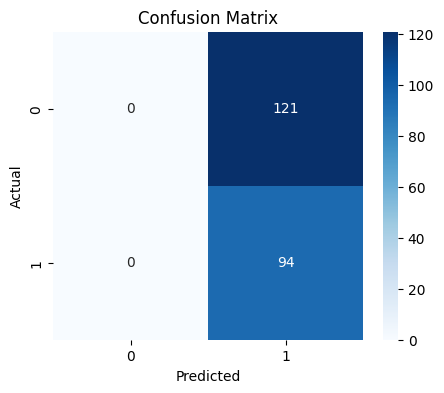

              precision    recall  f1-score   support

        Bird       0.00      0.00      0.00       121
       Drone       0.44      1.00      0.61        94

    accuracy                           0.44       215
   macro avg       0.22      0.50      0.30       215
weighted avg       0.19      0.44      0.27       215



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# ================================
# GET PREDICTIONS
# ================================

# Predict on test data
predictions = model.predict(test_generator)

# Convert probabilities → binary (0 or 1)
y_pred = (predictions > 0.5).astype(int).reshape(-1)

# ================================
# TRUE LABELS
# ================================

y_true = test_generator.classes

# ================================
# CONFUSION MATRIX
# ================================

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()
# ================================
# CLASSIFICATION REPORT
# ================================

from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=['Bird', 'Drone']
))





In [ ]:
# ================================
# TRANSFER LEARNING - PHASE 2 (FINE-TUNING)
# ================================

# 🔹 Unfreeze top layers of base model

for layer in base_model.layers[-30:]:   # unfreeze last 30 layers
    layer.trainable = True

# ================================
# RECOMPILE MODEL (VERY IMPORTANT)
# ================================

from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),  # very low LR
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

# ================================
# CALLBACKS
# ================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "efficientnet_phase2.keras",
    monitor='val_loss',
    save_best_only=True
)

# ================================
# TRAIN AGAIN
# ================================

history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint]
)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 1,660,257 (6.33 MB)

 Non-trainable params: 2,553,411 (9.74 MB)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 90s 748ms/step - accuracy: 0.5173 - loss: 0.7092 - val_accuracy: 0.5701 - val_loss: 0.6927
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 39s 464ms/step - accuracy: 0.5083 - loss: 0.7080 - val_accuracy: 0.5090 - val_loss: 0.6934
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 456ms/step - accuracy: 0.5128 - loss: 0.7025 - val_accuracy: 0.5090 - val_loss: 0.6942
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 452ms/step - accuracy: 0.5030 - loss: 0.7029 - val_accuracy: 0.5090 - val_loss: 0.6954
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 455ms/step - accuracy: 0.5135 - loss: 0.7003 - val_accuracy: 0.5090 - val_loss: 0.6940
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 39s 462ms/step - accuracy: 0.5071 - loss: 0.6983 - val_accuracy: 0.5090 - val_loss: 0.6922
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 457ms/step - accuracy: 0.5214 - loss: 0.6997 - val_accuracy: 0.5090 - val_loss: 0.6925
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 39s 462ms/step - accuracy: 0.5098 - loss: 0.6989 - val_accu

7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step


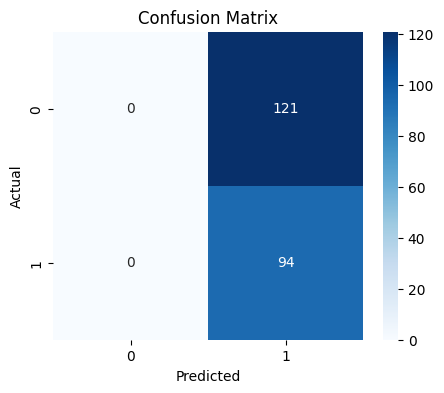

              precision    recall  f1-score   support

        Bird       0.00      0.00      0.00       121
       Drone       0.44      1.00      0.61        94

    accuracy                           0.44       215
   macro avg       0.22      0.50      0.30       215
weighted avg       0.19      0.44      0.27       215



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# ================================
# GET PREDICTIONS
# ================================

# Predict on test data
predictions = model.predict(test_generator)

# Convert probabilities → binary (0 or 1)
y_pred = (predictions > 0.5).astype(int).reshape(-1)

# ================================
# TRUE LABELS
# ================================

y_true = test_generator.classes

# ================================
# CONFUSION MATRIX
# ================================

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# ================================
# CLASSIFICATION REPORT
# ================================

from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=['Bird', 'Drone']
))


###ResNet50

In [ ]:
# ================================
# RESNET50 MODEL
# ================================

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Load base model
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze layers
for layer in base_model.layers:
    layer.trainable = False

# Build model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ================================
# CALLBACKS
# ================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "resnet.keras",
    monitor='val_loss',
    save_best_only=True
)


# Train
history_eff = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint]
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 67s 642ms/step - accuracy: 0.5413 - loss: 0.7431 - val_accuracy: 0.6335 - val_loss: 0.6412
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 41s 492ms/step - accuracy: 0.5612 - loss: 0.6924 - val_accuracy: 0.6471 - val_loss: 0.6275
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 41s 493ms/step - accuracy: 0.6041 - loss: 0.6610 - val_accuracy: 0.6380 - val_loss: 0.6232
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 82s 495ms/step - accuracy: 0.6056 - loss: 0.6525 - val_accuracy: 0.6538 - val_loss: 0.6178
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 41s 487ms/step - accuracy: 0.6270 - loss: 0.6434 - val_accuracy: 0.6357 - val_loss: 0.6222
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 42s 495ms/step - accuracy: 0.6289 - loss: 0.6384 - val_accuracy: 0.6471 - val_loss: 0.6104
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 40s 478ms/step - accuracy: 0.6458 - loss: 0.6409 - val_accuracy: 0.6471 - val_loss: 0.6275
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 40s 478ms/step - accuracy: 0.6375 - loss: 0.6359 - val_accu

7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step


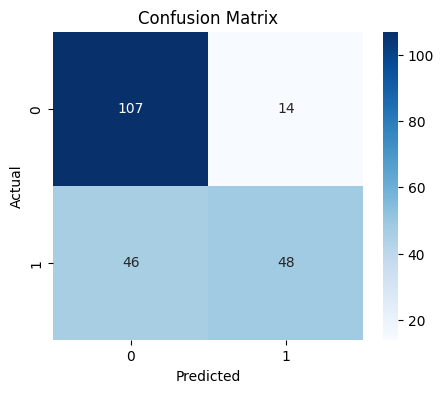

              precision    recall  f1-score   support

        Bird       0.70      0.88      0.78       121
       Drone       0.77      0.51      0.62        94

    accuracy                           0.72       215
   macro avg       0.74      0.70      0.70       215
weighted avg       0.73      0.72      0.71       215



In [ ]:
# ================================
# GET PREDICTIONS
# ================================

# Predict on test data
predictions = model.predict(test_generator)

# Convert probabilities → binary (0 or 1)
y_pred = (predictions > 0.5).astype(int).reshape(-1)

# ================================
# TRUE LABELS
# ================================

y_true = test_generator.classes

# ================================
# CONFUSION MATRIX
# ================================

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# ================================
# CLASSIFICATION REPORT
# ================================

from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=['Bird', 'Drone']
))


In [ ]:
# ================================
# TRANSFER LEARNING - PHASE 2 (FINE-TUNING)
# ================================

# 🔹 Unfreeze top layers of base model

for layer in base_model.layers[-30:]:   # unfreeze last 30 layers
    layer.trainable = True

# ================================
# RECOMPILE MODEL (VERY IMPORTANT)
# ================================

from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),  # very low LR
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

# ================================
# CALLBACKS
# ================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "resnet_phase2.keras",
    monitor='val_loss',
    save_best_only=True
)

# ================================
# TRAIN AGAIN
# ================================

history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint]
)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 14,712,577 (56.12 MB)

 Non-trainable params: 9,137,536 (34.86 MB)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 76s 674ms/step - accuracy: 0.6525 - loss: 0.6370 - val_accuracy: 0.5090 - val_loss: 0.7680
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 43s 512ms/step - accuracy: 0.7269 - loss: 0.5302 - val_accuracy: 0.5090 - val_loss: 0.7029
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 44s 522ms/step - accuracy: 0.7573 - loss: 0.4993 - val_accuracy: 0.7805 - val_loss: 0.4888
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 43s 510ms/step - accuracy: 0.7720 - loss: 0.4783 - val_accuracy: 0.7760 - val_loss: 0.4557
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 43s 514ms/step - accuracy: 0.7787 - loss: 0.4609 - val_accuracy: 0.7919 - val_loss: 0.4258
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 43s 507ms/step - accuracy: 0.7735 - loss: 0.4617 - val_accuracy: 0.8009 - val_loss: 0.4215
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 43s 511ms/step - accuracy: 0.7904 - loss: 0.4391 - val_accuracy: 0.8213 - val_loss: 0.3979
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 42s 498ms/step - accuracy: 0.7881 - loss: 0.4507 - val_accu

7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 848ms/step


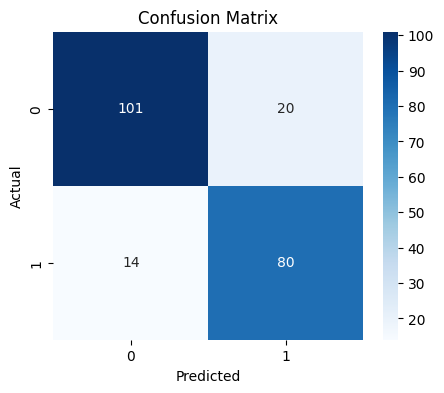

              precision    recall  f1-score   support

        Bird       0.88      0.83      0.86       121
       Drone       0.80      0.85      0.82        94

    accuracy                           0.84       215
   macro avg       0.84      0.84      0.84       215
weighted avg       0.84      0.84      0.84       215



In [ ]:
# ================================
# GET PREDICTIONS
# ================================

# Predict on test data
predictions = model.predict(test_generator)

# Convert probabilities → binary (0 or 1)
y_pred = (predictions > 0.5).astype(int).reshape(-1)

# ================================
# TRUE LABELS
# ================================

y_true = test_generator.classes

# ================================
# CONFUSION MATRIX
# ================================

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# ================================
# CLASSIFICATION REPORT
# ================================

from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=['Bird', 'Drone']
))


###DenseNet121

In [ ]:
# ================================
# DENSENET121 MODEL
# ================================

from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Load base model
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze layers
for layer in base_model.layers:
    layer.trainable = False

# Build model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ================================
# CALLBACKS
# ================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "densenet.keras",
    monitor='val_loss',
    save_best_only=True
)


# Train
history_eff = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint]
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,168,833 (27.35 MB)

 Trainable params: 131,329 (513.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 105s 926ms/step - accuracy: 0.7554 - loss: 0.4789 - val_accuracy: 0.9163 - val_loss: 0.2458
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 43s 509ms/step - accuracy: 0.8757 - loss: 0.2963 - val_accuracy: 0.9344 - val_loss: 0.1784
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 42s 496ms/step - accuracy: 0.9091 - loss: 0.2304 - val_accuracy: 0.9434 - val_loss: 0.1486
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 41s 493ms/step - accuracy: 0.9215 - loss: 0.1981 - val_accuracy: 0.9457 - val_loss: 0.1339
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 44s 521ms/step - accuracy: 0.9290 - loss: 0.1828 - val_accuracy: 0.9548 - val_loss: 0.1212
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 42s 494ms/step - accuracy: 0.9350 - loss: 0.1705 - val_accuracy: 0.9525 - val_loss: 0.1128
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 41s 491ms/step - accuracy: 0.9429 - loss: 0.1565 - val_accuracy: 0.9525 - val_loss: 0.1065
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 83s 503ms/step - accuracy: 0.9452 - loss: 0.1386 - val_acc

7/7 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step


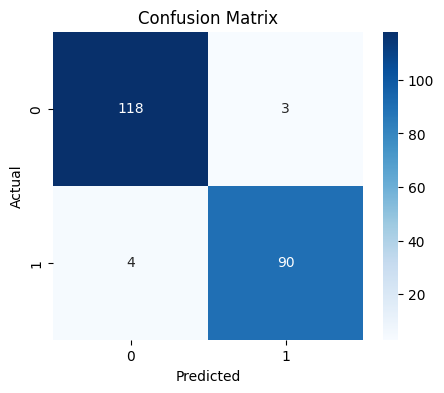

              precision    recall  f1-score   support

        Bird       0.97      0.98      0.97       121
       Drone       0.97      0.96      0.96        94

    accuracy                           0.97       215
   macro avg       0.97      0.97      0.97       215
weighted avg       0.97      0.97      0.97       215



In [ ]:
# ================================
# GET PREDICTIONS
# ================================

# Predict on test data
predictions = model.predict(test_generator)

# Convert probabilities → binary (0 or 1)
y_pred = (predictions > 0.5).astype(int).reshape(-1)

# ================================
# TRUE LABELS
# ================================

y_true = test_generator.classes

# ================================
# CONFUSION MATRIX
# ================================

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# ================================
# CLASSIFICATION REPORT
# ================================

from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=['Bird', 'Drone']
))


In [ ]:
# ================================
# TRANSFER LEARNING - PHASE 2 (FINE-TUNING)
# ================================

# 🔹 Unfreeze top layers of base model

for layer in base_model.layers[-30:]:   # unfreeze last 30 layers
    layer.trainable = True

# ================================
# RECOMPILE MODEL (VERY IMPORTANT)
# ================================

from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),  # very low LR
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

# ================================
# CALLBACKS
# ================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "densenet_phase2.keras",
    monitor='val_loss',
    save_best_only=True
)

# ================================
# TRAIN AGAIN
# ================================

history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint]
)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,168,833 (27.35 MB)

 Trainable params: 772,737 (2.95 MB)

 Non-trainable params: 6,396,096 (24.40 MB)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 112s 962ms/step - accuracy: 0.9324 - loss: 0.1783 - val_accuracy: 0.9706 - val_loss: 0.0912
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 43s 506ms/step - accuracy: 0.9474 - loss: 0.1345 - val_accuracy: 0.9638 - val_loss: 0.0909
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 42s 501ms/step - accuracy: 0.9508 - loss: 0.1381 - val_accuracy: 0.9638 - val_loss: 0.0894
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 42s 502ms/step - accuracy: 0.9482 - loss: 0.1343 - val_accuracy: 0.9638 - val_loss: 0.0878
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 43s 509ms/step - accuracy: 0.9530 - loss: 0.1226 - val_accuracy: 0.9638 - val_loss: 0.0859
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 42s 502ms/step - accuracy: 0.9489 - loss: 0.1252 - val_accuracy: 0.9638 - val_loss: 0.0845
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 42s 495ms/step - accuracy: 0.9452 - loss: 0.1399 - val_accuracy: 0.9683 - val_loss: 0.0832
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 43s 509ms/step - accuracy: 0.9504 - loss: 0.1235 - val_acc

7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step


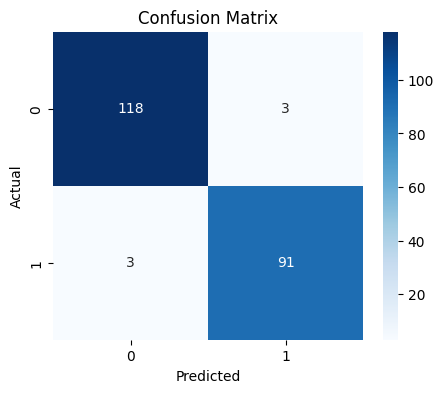

              precision    recall  f1-score   support

        Bird       0.98      0.98      0.98       121
       Drone       0.97      0.97      0.97        94

    accuracy                           0.97       215
   macro avg       0.97      0.97      0.97       215
weighted avg       0.97      0.97      0.97       215



In [ ]:
# ================================
# GET PREDICTIONS
# ================================

# Predict on test data
predictions = model.predict(test_generator)

# Convert probabilities → binary (0 or 1)
y_pred = (predictions > 0.5).astype(int).reshape(-1)

# ================================
# TRUE LABELS
# ================================

y_true = test_generator.classes

# ================================
# CONFUSION MATRIX
# ================================

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# ================================
# CLASSIFICATION REPORT
# ================================

from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=['Bird', 'Drone']
))


###Model Comparison

In [ ]:
# ================================
# STORE MODEL RESULTS
# ================================

model_results = {
    "custom CNN":0.85,
    "MobileNetV2-p1": 0.97,
    "MobileNetV2-p2": 0.99,
    "EfficientNetB0-p1": 0.44,
    "EfficientNetB0-p2": 0.44,
    "ResNet50-p1": 0.72,
    "ResNet50-p2": 0.82,
    "DenseNet121-p1": 0.97,
    "DenseNet121-p2": 0.97
}

In [ ]:
import pandas as pd

df = pd.DataFrame(list(model_results.items()), columns=["Model", "Accuracy"])
df

,Model,Accuracy
0,custom CNN,0.85
1,MobileNetV2-p1,0.97
2,MobileNetV2-p2,0.99
3,EfficientNetB0-p1,0.44
4,EfficientNetB0-p2,0.44
5,ResNet50-p1,0.72
6,ResNet50-p2,0.82
7,DenseNet121-p1,0.97
8,DenseNet121-p2,0.97


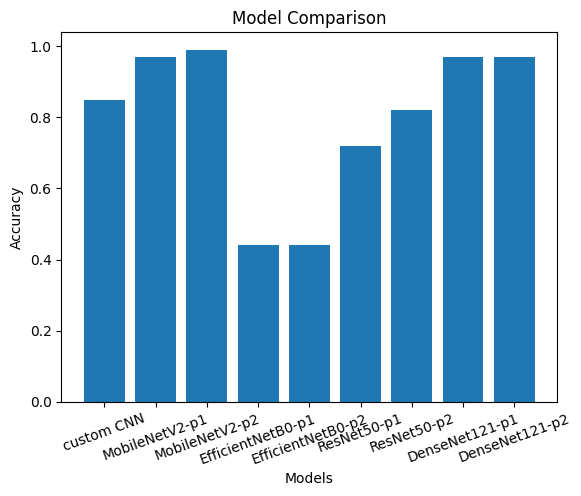

In [ ]:
import matplotlib.pyplot as plt

models = list(model_results.keys())
accuracies = list(model_results.values())

plt.figure()
plt.bar(models, accuracies)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")

plt.xticks(rotation=20)
plt.show()

##YOLOv8 Object Detection

In [ ]:
# ==========================================
# STEP 1: INSTALL ULTRALYTICS (YOLOv8)
# ==========================================

# Install YOLOv8 library
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.3 MB/s eta 0:00:00


In [ ]:
# ==========================================
# STEP 2: IMPORT YOLO CLASS
# ==========================================

from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# Unzip datasets
!unzip train-20260413T145527Z-3-001.zip
!unzip valid-20260413T142951Z-3-001.zip
!unzip test-20260413T142944Z-3-001.zip

Streaming output truncated to the last 5000 lines.
  inflating: train/images/pic_104_jpg.rf.3427145d4e749a9d89df95f3bf25df7a.jpg  
  inflating: train/images/pic_1068_jpg.rf.e097e6168353422d6d51d0a22b966724.jpg  
  inflating: train/images/pic_1026_jpg.rf.1a311c612622086d86190d5c8c82e6b5.jpg  
  inflating: train/images/pic_077_jpg.rf.9d8ea676aac3e6bf35602c714dd28c03.jpg  
  inflating: train/images/pic_052_jpg.rf.d005f5a0fdd4c565ed69c0f980c47778.jpg  
  inflating: train/images/pic_1070_jpg.rf.908338d4d74ba998a8d2f9d1b8769253.jpg  
  inflating: train/images/pic_048_jpg.rf.417e46b5aa8489a6c02e84f7f9bda43e.jpg  
  inflating: train/images/pic_1057_jpg.rf.5288a684d5a74dc242ca016997b23c60.jpg  
  inflating: train/images/pic_1075_jpg.rf.63f064d8da9d822fd00dc10c86275a87.jpg  
  inflating: train/images/pic_086_jpg.rf.328afd9f785e4de20d0a0b2c3718698d.jpg  
  inflating: train/images/pic_1056_jpg.rf.273b0770f0b08023f7868b7efb479a31.jpg  
  inflating: train/images/pic_056_jpg.rf.7b1dfc92900f6f255e9a95

In [ ]:
import os

print("Train:", os.listdir("train"))
print("Valid:", os.listdir("valid"))
print("Test:", os.listdir("test"))

Train: ['images', 'labels']
Valid: ['images', 'labels']
Test: ['images', 'labels']


In [ ]:
with open("data.yaml", "r") as f:
    print(f.read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 2
names: ['Bird', 'drone']

roboflow:
  workspace: new-workspace-x00wt
  project: drones-and-birds-0muie
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/new-workspace-x00wt/drones-and-birds-0muie/dataset/1


In [ ]:
# ==========================================
# STEP 3: FIX data.yaml PATHS FOR COLAB
# ==========================================

# In Colab, all files are inside /content/
# So I update paths accordingly

data_yaml = """
# Root directory of dataset
path: /content

# Train, validation and test image paths
train: train/images
val: valid/images
test: test/images

# Number of classes
nc: 2

# Class names
names:
  0: Bird
  1: drone
"""

# Write updated YAML file
with open("data.yaml", "w") as f:
    f.write(data_yaml)

print("✅ data.yaml updated successfully!")

✅ data.yaml updated successfully!


In [ ]:
# ==========================================
# STEP 4: VERIFY DATASET STRUCTURE
# ==========================================

import os

# Check train folder
print("Train folder:", os.listdir("/content/train"))

# Check validation folder
print("Valid folder:", os.listdir("/content/valid"))

# Check test folder
print("Test folder:", os.listdir("/content/test"))

Train folder: ['images', 'labels']
Valid folder: ['images', 'labels']
Test folder: ['images', 'labels']


In [ ]:
# ==========================================
# STEP 5: LOAD PRETRAINED YOLO MODEL
# ==========================================

# Load YOLOv8 nano model (lightweight & fast)
model = YOLO("yolov8n.pt")

In [ ]:
# ==========================================
# STEP 6: TRAIN YOLO MODEL
# ==========================================

# Train the model using your dataset
model.train(
    data="data.yaml",   # path to YAML file
    epochs=30,          # number of training epochs
    imgsz=768,          # image size
    batch=16            # batch size
)

# After training, results are saved in:
# runs/detect/train/

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=768, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, pl

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a050d11db80>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [ ]:
# ==========================================
# yolov8s model
# ==========================================

from ultralytics import YOLO

# Using slightly bigger model
model = YOLO("yolov8s.pt")

# Training with better settings
model.train(
    data="data.yaml",
    epochs=50,       # more training
    imgsz=768,       # better detection
    batch=16
)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=768, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, pl

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e1f54c3c830>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [ ]:
# ==========================================
# yolov8m model
# ==========================================

from ultralytics import YOLO

model = YOLO("yolov8m.pt")

model.train(
    data="data.yaml",
    epochs=50,
    imgsz=768,   # important for small drones
    batch=16
)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=768, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, p

In [ ]:
# ==========================================
# STEP 7: VALIDATE MODEL PERFORMANCE
# ==========================================

# Evaluate model on validation dataset
metrics = model.val()

# Print evaluation metrics
print(metrics)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 874.5±345.9 MB/s, size: 24.2 KB)
val: Scanning /content/valid/labels.cache... 448 images, 6 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 448/448 98.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 4.4it/s 6.3s
                   all        448        663      0.829      0.743      0.806      0.508
                  Bird        217        414      0.794      0.611      0.697      0.407
                 drone        225        249      0.864      0.876      0.916       0.61
Speed: 2.7ms preprocess, 5.2ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /content/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.uti

In [ ]:
# ==========================================
# STEP 8: RUN OBJECT DETECTION
# ==========================================

# Perform detection on test images
results = model.predict(
    source="/content/test/images",  # test images folder
    save=True                       # save output images
)

# Output images will be saved in:
# runs/detect/predict/


image 1/224 /content/test/images/00083b384685315d_jpg.rf.abfd1b2cc8c681777bae66d5327bb9ea.jpg: 768x768 1 Bird, 10.5ms
image 2/224 /content/test/images/00188d7f40a84793_jpg.rf.7f9da2b662dc236fbdcc1f22d8e0983e.jpg: 768x768 1 Bird, 8.5ms
image 3/224 /content/test/images/0028adf0e92c3da2_jpg.rf.48c97d30547a46e83abcbd1bf801c72f.jpg: 768x768 1 Bird, 8.5ms
image 4/224 /content/test/images/00347cbbeed4bedb_jpg.rf.aa19c9a7a22d76f8539ca12ac7cb82d5.jpg: 768x768 (no detections), 8.4ms
image 5/224 /content/test/images/004cc8de466969bc_jpg.rf.ca1ffa31f30a92a3987e689583983973.jpg: 768x768 1 Bird, 8.4ms
image 6/224 /content/test/images/006ce62a72df4dd4_jpg.rf.8f8e7b6e9a26a01be91ea1b7dc4011d2.jpg: 768x768 1 Bird, 8.4ms
image 7/224 /content/test/images/006f6769070fc876_jpg.rf.bda2b07a999cd589936497151e0d009f.jpg: 768x768 2 Birds, 8.4ms
image 8/224 /content/test/images/007321d46c4b8ffe_jpg.rf.bdea1bdbdba77545bc506d5f7a6cd306.jpg: 768x768 1 Bird, 8.4ms
image 9/224 /content/test/images/0078fb03bcd9e384_jp

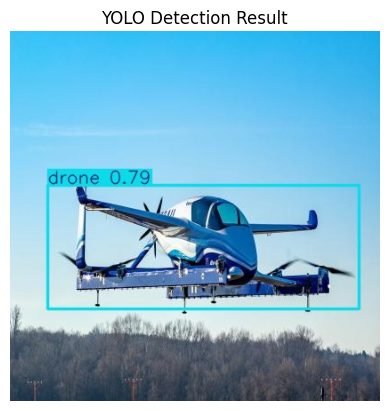

In [ ]:
# ==========================================
# STEP 9: DISPLAY PREDICTION RESULT
# ==========================================

from PIL import Image
import matplotlib.pyplot as plt

# Replace with actual image name from predict folder
img_path = "/content/runs/detect/predict/pic_189_jpg.rf.64a6e552dba3c18b135fc5c35a6999b2.jpg"
# Load and display image
img = Image.open(img_path)

plt.imshow(img)
plt.axis("off")
plt.title("YOLO Detection Result")
plt.show()